# ACE trajectories example


In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import importlib

# Define project root (run from MHDTurbPy repository root)
root_dir  = 'C:\\Users\\nokni\\work\\MHDTurbPy\\'

sc_pos_path = Path(root_dir).joinpath("functions", "sc_pos")
sys.path.insert(0, str(sc_pos_path))

import interactive_orbits_timeseries_plus3d as orbits
importlib.reload(orbits)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'interactive_orbits_timeseries_plus3d' from 'C:\\Users\\nokni\\work\\MHDTurbPy\\functions\\sc_pos\\interactive_orbits_timeseries_plus3d.py'>

## Build the 3D trajectory figure


[3D] Building 3D figure in frame3d=GSE (positions in AU).
[3D] GSE mode: single geocentric panel with axis/sun-wind guides (no Sun backmapping inset).
INFO: Obtained JPL HORIZONS location for Earth (399) [sunpy.coordinates.ephemeris]


C:\Users\nokni\work\MHDTurbPy\functions\sc_pos\interactive_orbits_timeseries_plus3d.py:332: UserWarning:

Discarding nonzero nanoseconds in conversion.



[3D] Adding ecliptic plane patch in target frame.
[3D] ACE: fetching ephemeris (SPKID=-92), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]
[3D] WIND: fetching ephemeris (SPKID=-8), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]
[3D] DISCOVER: fetching ephemeris (SPKID=-78), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for DSCOVR (spacecraft) (-78) [sunpy.coordinates.ephemeris]
[3D] ADITYA: fetching ephemeris (SPKID=-170), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for James Webb Space Telescope (spac [sunpy.coordinates.ephemeris]
[3D] IMAP: fetching ephemeris (SPKID=-43), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43) [sunpy.coordinates.ephemeris]
[3D] SOLAR-1: fetching ephemeris (SPKID=-231), building 

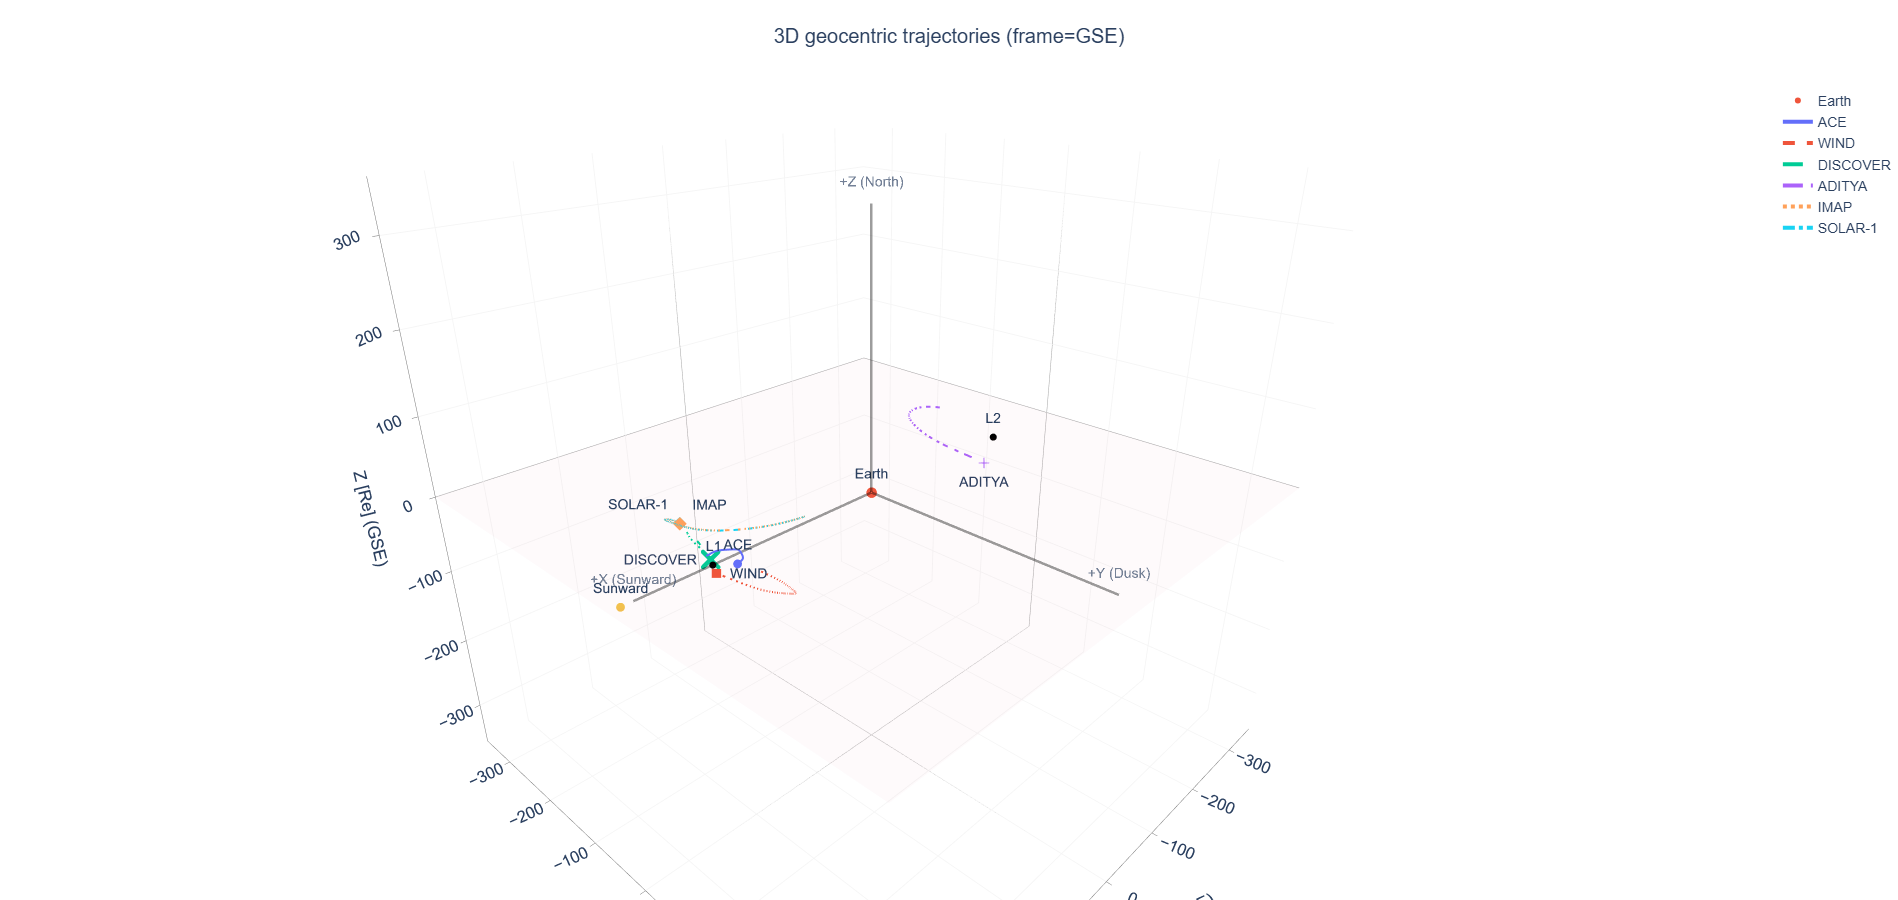

In [9]:
targets = ["ACE", "WIND", "DISCOVER", 'ADITYA', "IMAP", 'SOLAR-1']

fig_3d = orbits.build_3d_figure(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="202-12-10T00:00:00",
    step="6h",
    frame3d="GSE",
    rss_rsun=20,
    #skip_small_bodies=True,
)

fig_3d.show()


## Build synchronized longitude/latitude time series


In [ ]:
fig_ts = orbits.build_timeseries_figure(
    targets=targets,
    start="2021-10-01T00:00:00",
    stop="2021-12-10T00:00:00",
    step="6h",
    lon_unwrap_deg=False,
)

fig_ts.show()


## MRE: first-principles stream-separation metric (step by step)

This minimal reproducible example (MRE) intentionally keeps a few assumptions fixed so the method is transparent:

- **Hardcoded/assumed in this notebook run:** `flow_dir_gse=(-1,0,0)`, constant `vsw_kms=400`, `perp_scale=0.35`, `lag_tolerance=0.5`.
- **Why this is limited:** real solar wind has time-varying speed and flow direction, and anisotropy changes with conditions.
- **How to improve with real data:** replace constants by measured `Vsw(t)`, infer local flow direction from plasma moments, and make decorrelation scales time dependent.

The solver minimizes a conservative estimate of the probability that **all** selected spacecraft observe the same stream.


INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for DSCOVR (spacecraft) (-78) [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for James Webb Space Telescope (spac [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43) [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]
[alignment] First-principles stream-separation model (GSE):
  1) Assumption: Taylor frozen-in flow with bulk speed Vsw.
  2) Pair physics: two spacecraft sample the same parcel with probability
       p_pair = exp(-(d_perp/L_perp)^2 - (tau/tau0)^2), tau=|d_parallel|/Vsw.
  3) All-spacecraft logic (conservative):
       p_all_upper = min(p_pair), p_all_indep = product(p_pair),
       p_all_ref = sqrt(p_all_upper * 

,window_start,window_end,alignment_metric,alignment_metric_p16,alignment_metric_p84,same_stream_prob,same_stream_prob_p16,same_stream_prob_p84,same_flow_score,same_flow_score_p16,same_flow_score_p84
0,2025-11-21 12:00:00,2025-11-22 06:00:00,0.811659,0.811656,0.811667,0.800164,0.800152,0.800181,0.199836,0.199819,0.199848
1,2025-11-22 06:00:00,2025-11-23 00:00:00,0.811665,0.811658,0.811675,0.800139,0.800138,0.800141,0.199861,0.199859,0.199862
2,2025-11-20 18:00:00,2025-11-21 12:00:00,0.811704,0.811686,0.811726,0.800240,0.800213,0.800271,0.199760,0.199729,0.199787


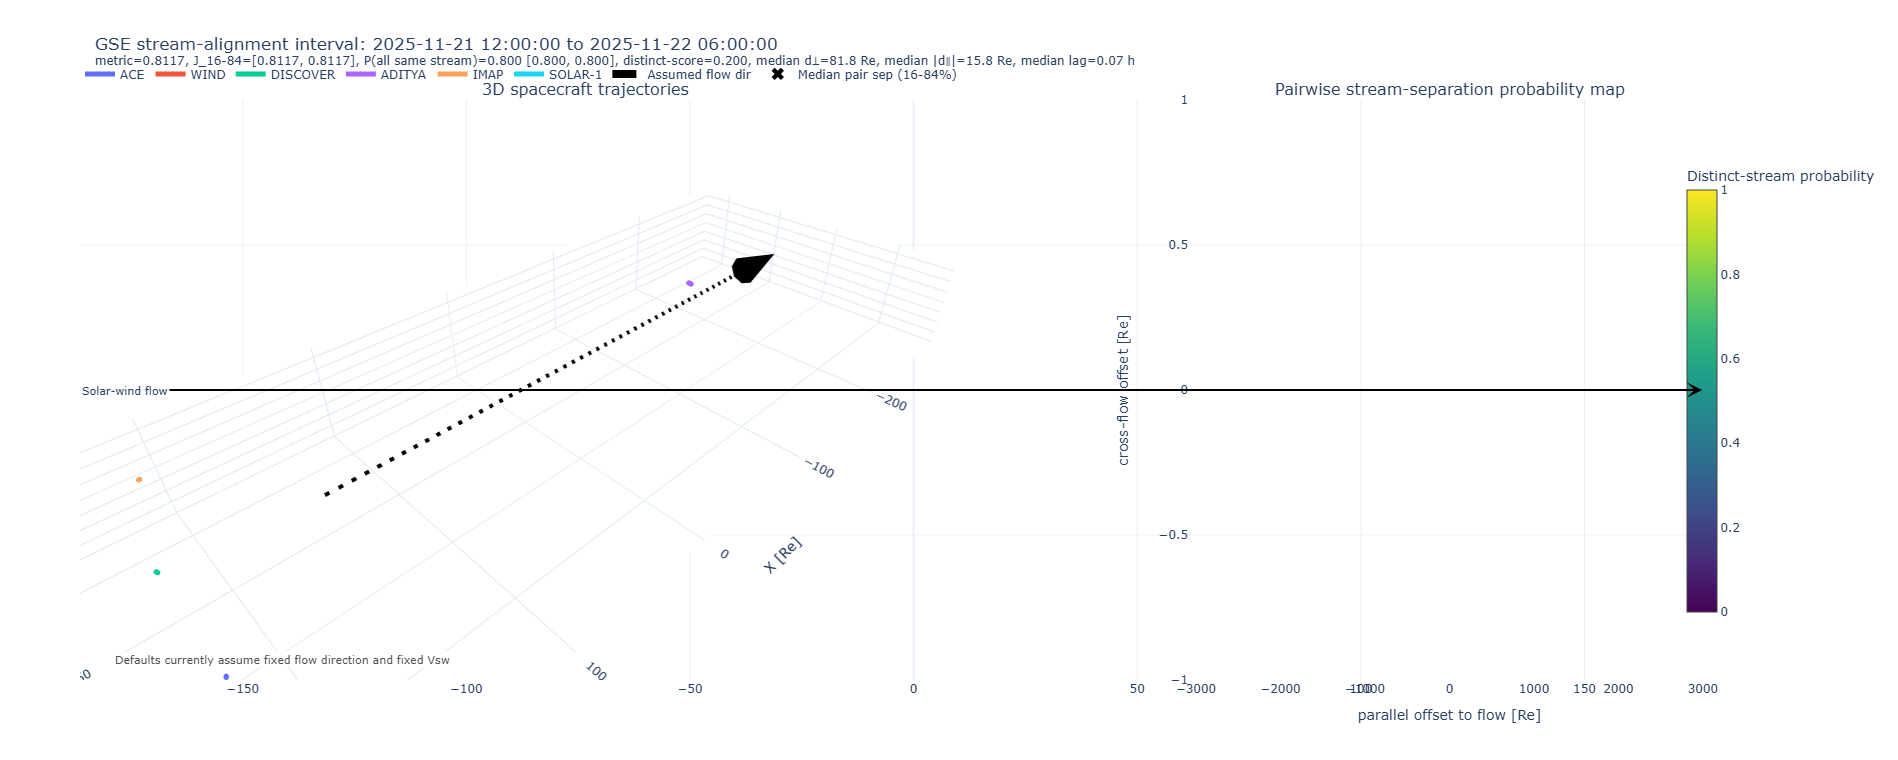

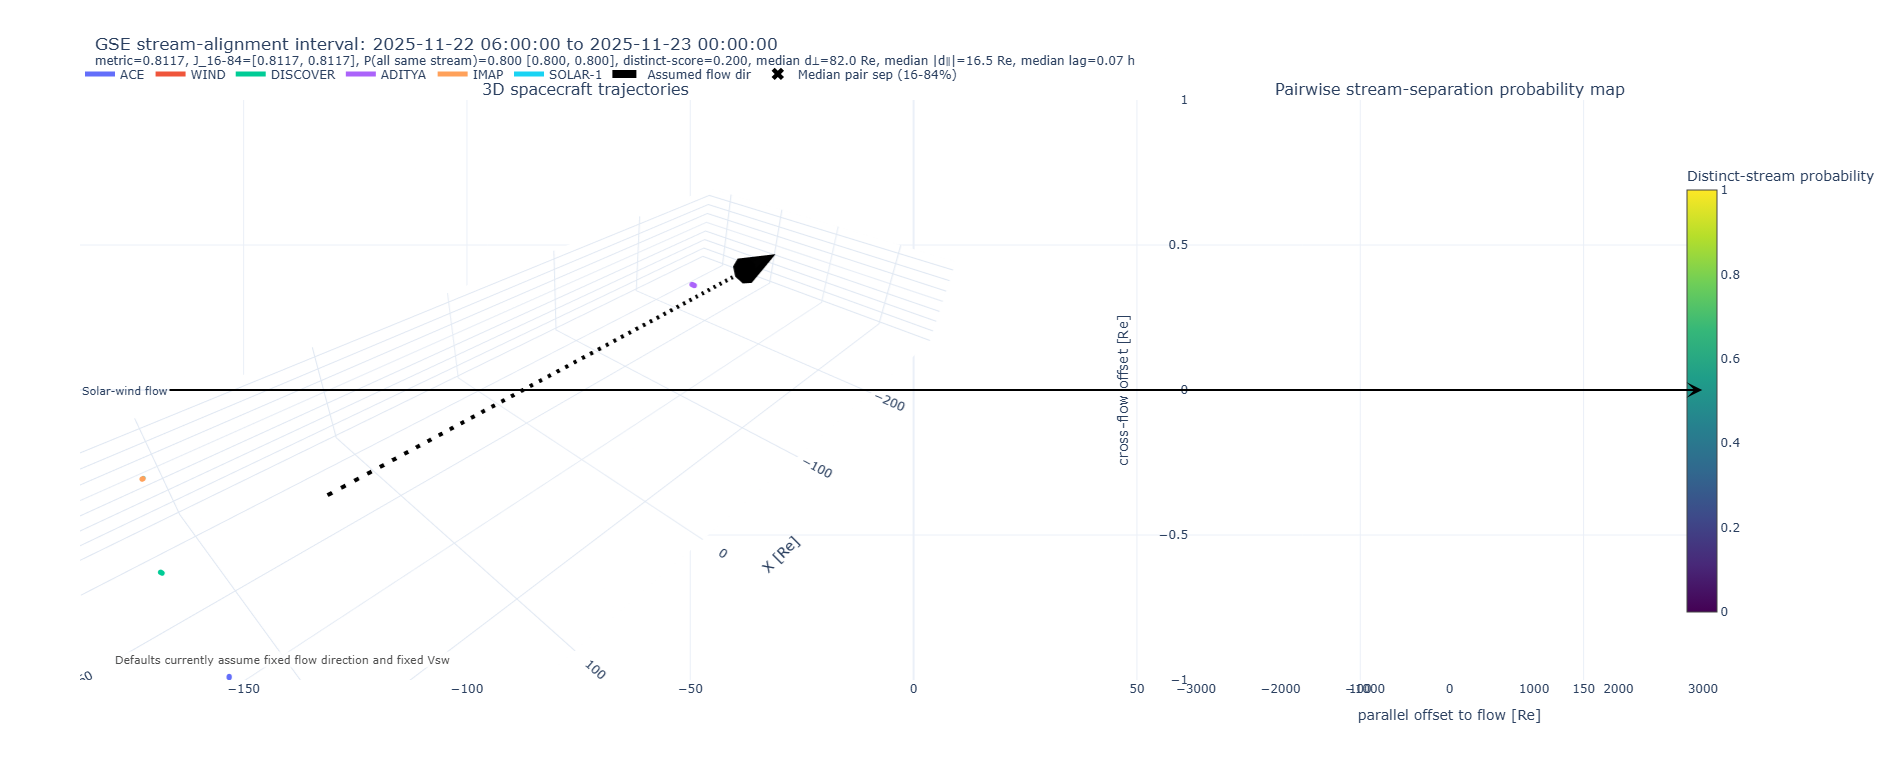

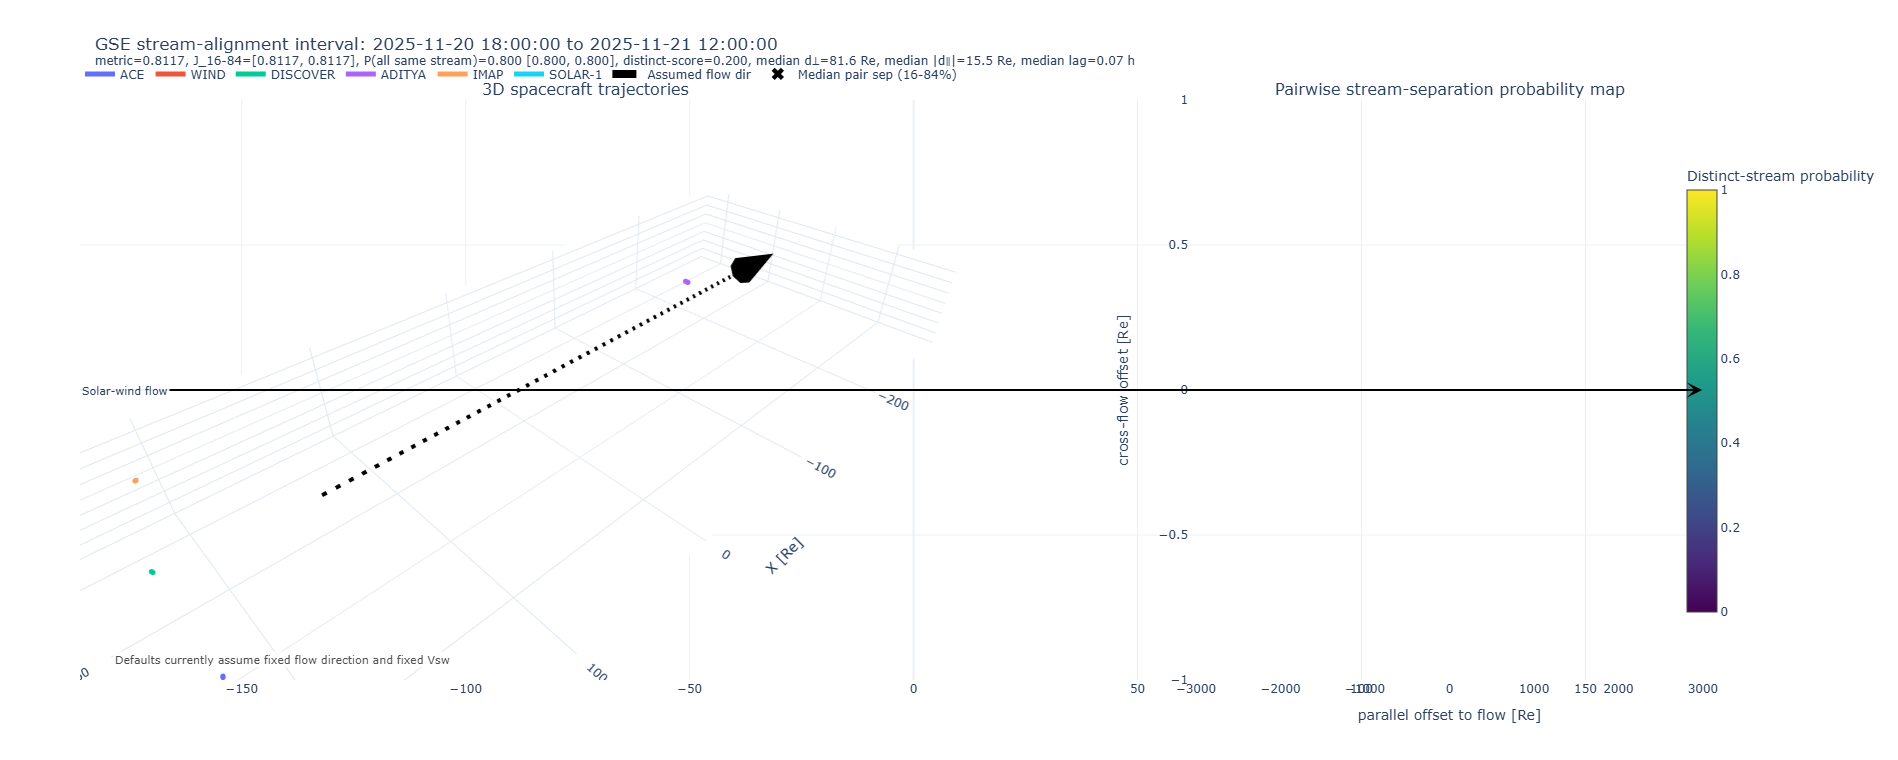

In [7]:
# Step 1: configure assumptions explicitly (so they are visible and reproducible)
metric_cfg = dict(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="3h",
    window_hours=18,
    top_n=3,
    flow_dir_gse=(-1.0, 0.0, 0.0),   # hardcoded Parker-like anti-sunward direction
    vsw_kms=400.0,                    # hardcoded constant speed [km/s]
    perp_scale=0.35,                  # hardcoded decorrelation scale fraction
    lag_tolerance=0.5,                # hardcoded lag tolerance fraction
    along_weight=0.25,
    min_coverage=0.8,
    verbose=True,
)

# Step 2: run first-principles window ranking
scores_out = orbits.find_best_stream_aligned_intervals(**metric_cfg)
best_windows = scores_out['best']
all_scores = scores_out['scores']

# Step 3: inspect numerical outputs with uncertainty bars (16th-84th percentile)
cols = [
    'window_start', 'window_end', 'alignment_metric', 'alignment_metric_p16', 'alignment_metric_p84',
    'same_stream_prob', 'same_stream_prob_p16', 'same_stream_prob_p84',
    'same_flow_score', 'same_flow_score_p16', 'same_flow_score_p84',
]
display(best_windows[cols])

# Step 4: build intuitive visualization for each selected interval
alignment_figs = []
for _, row in best_windows.iterrows():
    alignment_figs.append(
        orbits.plot_stream_alignment_interval(
            tracks=scores_out['tracks'],
            targets=targets,
            window_start=row['window_start'],
            window_end=row['window_end'],
            flow_hat=scores_out['flow_hat'],
            summary_row=row,
        )
    )

for fig in alignment_figs:
    fig.show()
